In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('exoplanets.csv', comment='#')
df.head

<bound method NDFrame.head of          kepid kepoi_name   kepler_name koi_disposition koi_vet_stat  \
0     10797460  K00752.01  Kepler-227 b       CONFIRMED         Done   
1     10797460  K00752.02  Kepler-227 c       CONFIRMED         Done   
2     10811496  K00753.01           NaN       CANDIDATE         Done   
3     10848459  K00754.01           NaN  FALSE POSITIVE         Done   
4     10854555  K00755.01  Kepler-664 b       CONFIRMED         Done   
...        ...        ...           ...             ...          ...   
9559  10090151  K07985.01           NaN  FALSE POSITIVE         Done   
9560  10128825  K07986.01           NaN       CANDIDATE         Done   
9561  10147276  K07987.01           NaN  FALSE POSITIVE         Done   
9562  10155286  K07988.01           NaN       CANDIDATE         Done   
9563  10156110  K07989.01           NaN  FALSE POSITIVE         Done   

     koi_vet_date koi_pdisposition  koi_score  koi_fpflag_nt  koi_fpflag_ss  \
0      2018-08-16        C

Our target variable is the koi_disposition (CONFIRMED, CANDIDATE, FALSE POSITIVE).
Our input to the models will be:
- the koi period (AKA Orbital period in days)
- koi duration (Transit Duration in hrs): the length of time a planet takes to cross in front of its star, measured from first to last contact
- koi depth (Transit Depth in ppm): the fractional amount of a star's light that is blocked when a planetary transit occurs
- koi_prad: Planetary radius (compared to Earth's radius)
- koi_teq: Equilibrium temp (measured in K)
- koi_steff: Stellar Effective temp (K)
- koi_srad: stellar radius (compared to radius of sun)




https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative

https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html

Other columns like koi_fgflag_nt are pre-calculated and can show if the obj is likely to be a false positive. If we kept this in, the model would learn patterns from this and would require this information in the future, rather than 'learning' the Physics itself.
Derived columns like koi_sma (Orbit Semi-Major Axis (Astronomical Unit (au)), derived from KL3), if kept would introduce multicollinerarity - a very high dependence on certain features that aren't representative of the actual relationships.

In [4]:
#only keep relevant variables
cleaned_df = df.loc[:,['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_steff', 'koi_srad', 'koi_disposition']]
cleaned_df.head

<bound method NDFrame.head of       koi_period  koi_duration  koi_depth  koi_prad  koi_teq  koi_steff  \
0       9.488036       2.95750      615.8      2.26    793.0     5455.0   
1      54.418383       4.50700      874.8      2.83    443.0     5455.0   
2      19.899140       1.78220    10829.0     14.60    638.0     5853.0   
3       1.736952       2.40641     8079.2     33.46   1395.0     5805.0   
4       2.525592       1.65450      603.3      2.75   1406.0     6031.0   
...          ...           ...        ...       ...      ...        ...   
9559    0.527699       3.22210     1579.2     29.35   2088.0     5638.0   
9560    1.739849       3.11400       48.5      0.72   1608.0     6119.0   
9561    0.681402       0.86500      103.6      1.07   2218.0     6173.0   
9562  333.486169       3.19900      639.1     19.30    557.0     4989.0   
9563    4.856035       3.07800       76.7      1.05   1266.0     6469.0   

      koi_srad koi_disposition  
0        0.927       CONFIRMED  
1  

In [6]:
cleaned_df["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

In [13]:
#what % of the kois are planets?
round((cleaned_df["koi_disposition"].value_counts()[1] / df.shape[0])* 100,2)

28.71

In [ ]:
#what % of the kois are false positives?
round((cleaned_df["koi_disposition"].value_counts()[0] / df.shape[0])* 100,2)

50.6

Text(0, 0.5, 'Count')

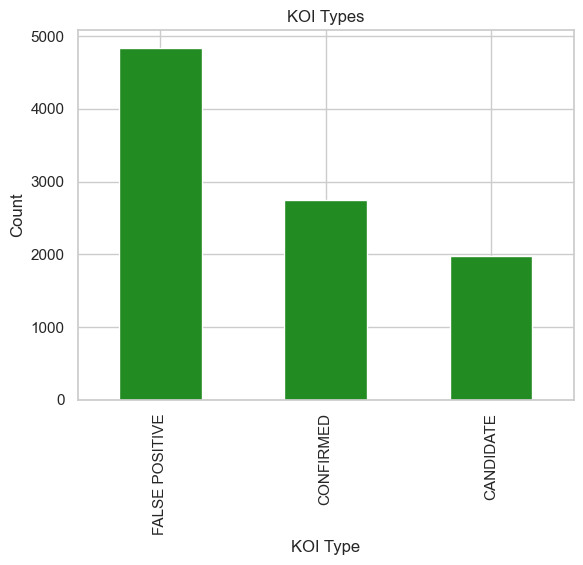

In [15]:
cleaned_df["koi_disposition"].value_counts().plot(kind="bar", title="KOI Types", color="forestgreen")
plt.xlabel("KOI Type")
plt.ylabel("Count")

In [16]:
cleaned_df["koi_period"].describe().astype(int)

count      9564
mean         75
std        1334
min           0
25%           2
50%           9
75%          40
max      129995
Name: koi_period, dtype: int32

Standard deviation is skewed upwards by the (anomalously) large maximum period.

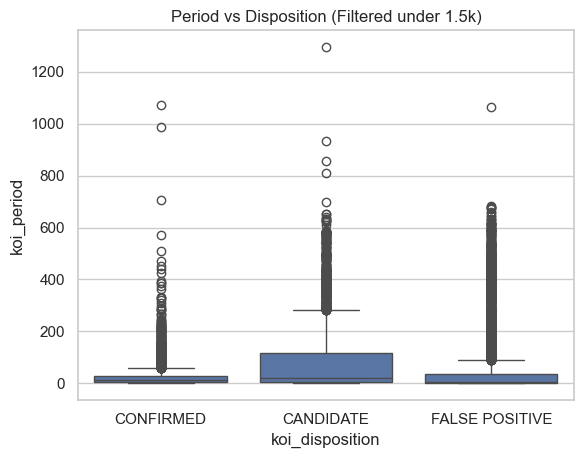

In [48]:
sns.boxplot(data= cleaned_df[cleaned_df["koi_period"]<1500], x ="koi_disposition", y="koi_period")
plt.title("Period vs Disposition (Filtered under 1.5k)")
plt.show()

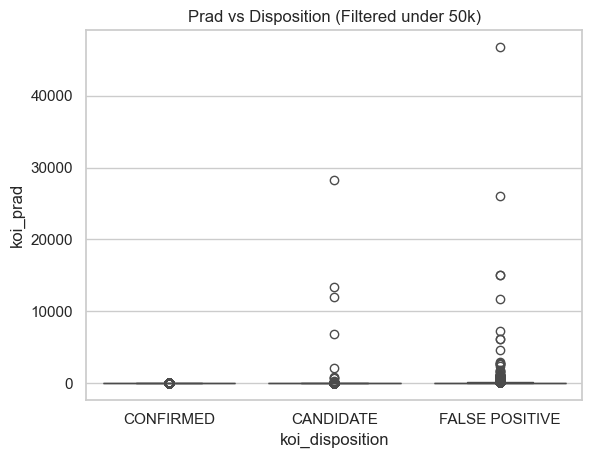

In [41]:
sns.boxplot(data= cleaned_df[cleaned_df["koi_prad"]<50000], x ="koi_disposition", y="koi_prad")
plt.title("Prad vs Disposition (Filtered under 50k)")
plt.show()

Data Preparation:
- For the supervised learning task, we'll transform this into a binary classification where 1 is 'CONFIRMED' and 0 is 'FALSE POSITIVE'

In [34]:
supervised_df = cleaned_df[cleaned_df["koi_disposition"].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
supervised_df["label"] = LabelEncoder().fit_transform(cleaned_df["koi_disposition"])

#feature selection
features = [
    'koi_period', 'koi_duration', 'koi_impact', 
    'koi_depth', 'koi_prad', 'koi_teq', 
    'koi_insol', 'koi_steff', 'koi_srad', 'koi_smass'
    ]

X = supervised_df[features]
y = supervised_df['label']

#handle missing data by filling with the mean of the column
X = X.fillna(X.mean())

#scaling balances impact of the features and reduced the influence of outliers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print(f"Target distribution (0=False Positive, 1=Confirmed): \n{y.value_counts()}")

Target distribution (0=False Positive, 1=Confirmed): 
label
1    4839
0    2746
Name: count, dtype: int64


For supervised learning, we'll be using a Random Forest Classifier.

Have a go changing the test_size and the number of estimators and see how/if this affects the accuracy.

In [15]:
#N.B. stratify ensures training and testing sets have the same proportion of classes as original data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


#estimators = small decision trees
model_supervised = RandomForestClassifier(n_estimators=120, random_state=42)
model_supervised.fit(X_train, y_train)

y_pred = model_supervised.predict(X_test)


Supervised Model Evaluation
Accuracy: 0.9130

Confusion Matrix:


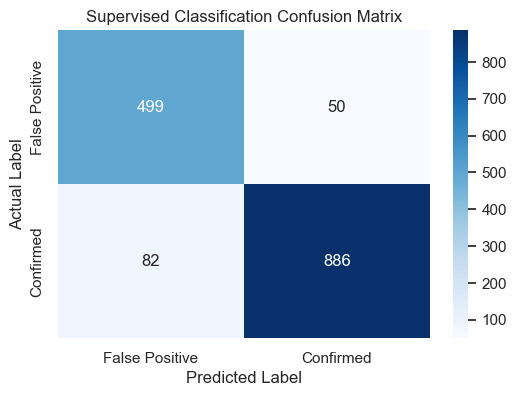

In [16]:
print("Supervised Model Evaluation")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
# Use a heatmap for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['False Positive', 'Confirmed'], 
            yticklabels=['False Positive', 'Confirmed'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Supervised Classification Confusion Matrix')
plt.show()


In [ ]:
pred_supervised_df = cleaned_df[cleaned_df["koi_disposition"].isin(['CANDIDATE'])].copy()
#feature selection
features = [
    'koi_period', 'koi_duration', 'koi_impact', 
    'koi_depth', 'koi_prad', 'koi_teq', 
    'koi_insol', 'koi_steff', 'koi_srad', 'koi_smass'
    ]

X_cand = pred_supervised_df[features]

#handle missing data by filling with the mean of the column
X_cand = X_cand.fillna(X.mean())

#scaling balances impact of the features and reduces the influence of outliers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cand)
y_pred = model_supervised.predict(X_test)

unique, counts = np.unique(pred_supervised_df, return_counts=True)

result = np.asarray((unique, counts))

In [ ]:
#Feature Importance
feature_importances = pd.Series(model_supervised.feature_importances_, index=features)
print("\nTop 5 Feature Importances:")
print(feature_importances.nlargest(5))



Top 5 Feature Importances:
koi_prad        0.223705
koi_period      0.121411
koi_insol       0.115822
koi_depth       0.111646
koi_duration    0.095415
dtype: float64


Unsupervised Learning
We can use this to see how the data naturally clusters and to check if there are other underlying patterns we can use without looking at the labels.

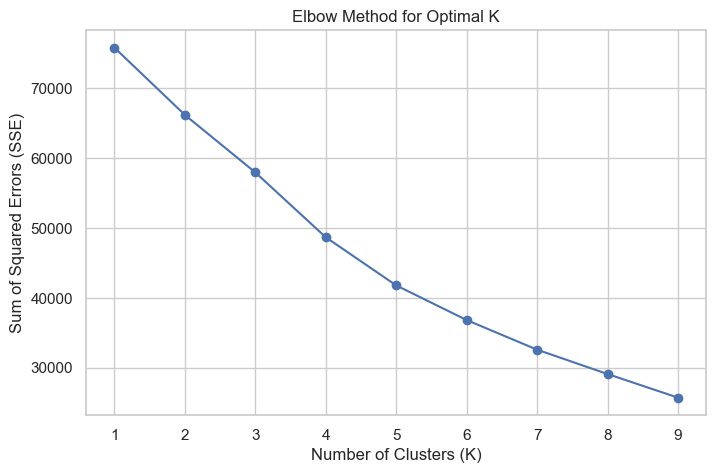

In [26]:
sse = []
max_k = 10
for k in range(1, max_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k), sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means with K=2 (or the value from the elbow plot)
# K=2 is often a good guess for 2 classes: CONFIRMED, FALSE POSITIVE
K = 2
model_unsupervised = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = model_unsupervised.fit_predict(X_scaled)
cleaned_df['Cluster'] = clusters

print(f"\nUnsupervised Model (K-Means with K={K}) trained.")


Unsupervised Model (K-Means with K=2) trained.


Silhouette score = a metric used to evaluate the quality of clustering in data, measuring how similar a data point is to its own cluster compared to other clusters.

In [31]:
# Unsupervised Evaluation (Silhouette Score)
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score (Measures cluster quality): {sil_score:.4f}")

Silhouette Score (Measures cluster quality): 0.9416


In [ ]:
#Compare clusters with the true supervised label
# This reveals if the clusters correspond to the true planetary dispositions
print("Cluster Analysis (Comparing Clusters to True Labels)")
cluster_summary = cleaned_df.groupby('Cluster')['koi_disposition'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
print(cluster_summary)

Cluster Analysis (Comparing Clusters to True Labels)
   Cluster koi_disposition  Percentage
0        0  FALSE POSITIVE   63.777866
1        0       CONFIRMED   36.222134
2        1  FALSE POSITIVE  100.000000
